# DeMemteAttractor: Residual Attractor Memory with Ambiguity Gate

Isolated VQ experiment for Issue #2. The model applies residual latent completion only when the input is ambiguous, partially familiar, internally conflicting, and not extreme OOD. The notebook reuses the Flowers-102 pipeline and corruption suite from the current VQ notebooks, pretrains a shared latent VQ space, then trains the proposed model and ablations from the same Phase 1 checkpoint.

In [1]:
import os
import copy
import glob
import json
import math
import random
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
try:
    import pandas as pd
except ImportError as exc:
    pd = None
    print('pandas unavailable; falling back to plain records:', exc)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())

torch: 2.4.1+cu121
torchvision: 0.19.1+cu121
cuda: True


In [2]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 16
    num_workers: int = 2

    val_ratio: float = 0.2
    split_seed: int = 42

    lr_vq: float = 3e-4
    lr_cls: float = 1e-4
    lr_attractor: float = 3e-4
    lr_gate: float = 1e-3
    weight_decay: float = 1e-4

    epochs_baseline_max: int = 30
    epochs_phase1_max: int = 4
    epochs_phase2_max: int = 6
    epochs_phase3_max: int = 10

    early_stop_patience: int = 3
    early_stop_min_delta: float = 1e-4
    scheduler_factor: float = 0.5
    scheduler_patience: int = 2

    latent_dim: int = 128
    attractor_hidden: int = 512
    gate_hidden: int = 16
    num_embeddings: int = 1024
    commitment_cost: float = 0.25
    vq_temperature: float = 1.0

    familiarity_midpoint: float = 0.0
    familiarity_width: float = 1.0
    ood_tau: float = 2.0
    ood_beta: float = 4.0

    denoise_weight: float = 0.5
    vq_weight: float = 0.25
    antipareidolia_weight: float = 0.1
    gate_entropy_reg: float = 0.01

    masked_feature_ratio: float = 0.35
    train_corrupt_prob: float = 0.7

    max_train_batches_debug: int = 10000000
    max_val_batches_debug: int = 10000000
    eval_max_batches: int = 10000000

    artifacts_root: str = './out/artifacts'
    experiment_name: str = 'dememte_attractor_memory'
    retrain_comparison_if_missing: bool = True

    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = Config()
device = torch.device(cfg.device)
criterion = nn.CrossEntropyLoss()
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "val_ratio": 0.2,
  "split_seed": 42,
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "lr_attractor": 0.0003,
  "lr_gate": 0.001,
  "weight_decay": 0.0001,
  "epochs_baseline_max": 30,
  "epochs_phase1_max": 4,
  "epochs_phase2_max": 6,
  "epochs_phase3_max": 10,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "latent_dim": 128,
  "attractor_hidden": 512,
  "gate_hidden": 16,
  "num_embeddings": 1024,
  "commitment_cost": 0.25,
  "vq_temperature": 1.0,
  "familiarity_midpoint": 0.0,
  "familiarity_width": 1.0,
  "ood_tau": 2.0,
  "ood_beta": 4.0,
  "denoise_weight": 0.5,
  "vq_weight": 0.25,
  "antipareidolia_weight": 0.1,
  "gate_entropy_reg": 0.01,
  "masked_feature_ratio": 0.35,
  "train_corrupt_prob": 0.7,
  "max_train_batches_debug": 10000000,
  "max_val_batches_debug": 10000000,
  "eval_max_batches": 10000000,
  "artifacts_root"

In [4]:
def _extract_labels(dataset):
    if hasattr(dataset, '_labels'):
        return np.array(dataset._labels)
    if hasattr(dataset, 'labels'):
        return np.array(dataset.labels)
    ys = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        ys.append(int(y))
    return np.array(ys)

def build_datasets(config: Config, download: bool = False):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    tr = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=download, transform=transform_train)
    va = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=download, transform=transform_train)
    te = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=download, transform=transform_eval)

    cv_ds = ConcatDataset([tr, va])
    cv_y = np.concatenate([_extract_labels(tr), _extract_labels(va)], axis=0)

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=config.val_ratio, random_state=config.split_seed)
    train_idx, val_idx = next(splitter.split(np.zeros(len(cv_y)), cv_y))

    tr_ds = Subset(cv_ds, train_idx.tolist())
    va_ds = Subset(cv_ds, val_idx.tolist())

    tr_loader = DataLoader(tr_ds, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    te_loader = DataLoader(te, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    return tr_loader, va_loader, te_loader

trainloader, valloader, testloader = build_datasets(cfg)
print('train batches:', len(trainloader), '| val batches:', len(valloader), '| test batches:', len(testloader))

100%|██████████| 344862509/344862509 [00:35<00:00, 9689675.25it/s] 


Extracting ../data/flowers-102/102flowers.tgz to ../data/flowers-102


100%|██████████| 502/502 [00:00<00:00, 264648.14it/s]


100%|██████████| 14989/14989 [00:00<00:00, 7349593.48it/s]

train batches: 102 | val batches: 26 | test batches: 385


In [5]:
def make_backbone():
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    return nn.Sequential(*list(base.children())[:-2])

def apply_train_corruption(x):
    if random.random() > cfg.train_corrupt_prob:
        return x

    mode = random.choice(['gaussian_noise', 'pixel_mask', 'cutout', 'blur'])

    if mode == 'gaussian_noise':
        level = random.uniform(0.4, 1.3)
        return x + level * torch.randn_like(x)

    if mode == 'pixel_mask':
        level = random.uniform(0.20, 0.65)
        keep = (torch.rand(x.size(0), 1, x.size(2), x.size(3), device=x.device) > level).float()
        return x * keep

    if mode == 'cutout':
        level = random.uniform(0.20, 0.45)
        b, _, h, w = x.shape
        cut_h = max(1, int(h * level))
        cut_w = max(1, int(w * level))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        for i in range(b):
            t = random.randint(0, max(0, h - cut_h))
            l = random.randint(0, max(0, w - cut_w))
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask

    level = random.uniform(0.30, 0.80)
    channels = x.size(1)
    kernel_size = 7
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype) / (kernel_size * kernel_size)
    blur = F.conv2d(x, weight, padding=kernel_size // 2, groups=channels)
    return (1.0 - level) * x + level * blur

In [6]:
class VectorQuantizer2D(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25, temperature=1.0):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.temperature = temperature
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z_e):
        b, c, h, w = z_e.shape
        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z_e_perm.view(-1, c)
        emb = self.embedding.weight
        distances = flat.pow(2).sum(1, keepdim=True) - 2 * flat @ emb.t() + emb.pow(2).sum(1, keepdim=True).t()
        idx = torch.argmin(distances, dim=1)
        one_hot = F.one_hot(idx, self.num_embeddings).type(flat.dtype)
        q_flat = one_hot @ emb
        q = q_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        vq_loss = self.commitment_cost * F.mse_loss(z_e, q.detach()) + F.mse_loss(q, z_e.detach())
        q_st = z_e + (q - z_e).detach()
        dq_map = ((z_e - q.detach()) ** 2).mean(dim=1, keepdim=True)
        temp = max(1e-6, float(self.temperature))
        soft_assign = F.softmax(-distances / temp, dim=1).view(b, h, w, self.num_embeddings)
        return q_st, vq_loss, dq_map, soft_assign

In [7]:
class LatentProjector(nn.Module):
    def __init__(self, in_channels=512, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, latent_dim, kernel_size=1),
            nn.BatchNorm2d(latent_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class LatentUnprojector(nn.Module):
    def __init__(self, latent_dim=128, out_channels=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.net(z)

In [8]:
class AttractorMemory(nn.Module):
    def __init__(self, latent_dim=128, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z):
        b, c, h, w = z.shape
        toks = z.flatten(2).transpose(1, 2).contiguous().view(b * h * w, c)
        completed = toks + self.net(toks)
        return completed.view(b, h * w, c).transpose(1, 2).view(b, c, h, w).contiguous()

In [9]:
class AmbiguityGate(nn.Module):
    def __init__(
        self,
        num_classes=102,
        num_embeddings=1024,
        hidden=16,
        familiarity_midpoint=0.0,
        familiarity_width=1.0,
        ood_tau=2.0,
        ood_beta=4.0,
        use_uncertainty=True,
        use_familiarity=True,
        use_conflict=True,
        use_ood=True,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.num_embeddings = num_embeddings
        self.ood_tau = ood_tau
        self.ood_beta = ood_beta
        self.use_uncertainty = use_uncertainty
        self.use_familiarity = use_familiarity
        self.use_conflict = use_conflict
        self.use_ood = use_ood

        self.midpoint = nn.Parameter(torch.tensor(float(familiarity_midpoint)))
        self.log_width = nn.Parameter(torch.log(torch.tensor(float(familiarity_width))))
        self.mlp = nn.Sequential(nn.Linear(4, hidden), nn.GELU(), nn.Linear(hidden, 1))

        self.register_buffer('dq_ema_mean', torch.tensor(0.0))
        self.register_buffer('dq_ema_var', torch.tensor(1.0))
        self.register_buffer('dq_ema_counted', torch.tensor(0.0))

    def _update_ema(self, dq_score):
        with torch.no_grad():
            batch_mean = dq_score.mean()
            batch_var = dq_score.var(unbiased=False) if dq_score.numel() > 1 else torch.tensor(0.0, device=dq_score.device)
            momentum = 0.99
            if self.dq_ema_counted.item() == 0:
                self.dq_ema_mean.fill_(batch_mean)
                self.dq_ema_var.fill_(batch_var)
            else:
                self.dq_ema_mean.mul_(momentum).add_(batch_mean * (1 - momentum))
                self.dq_ema_var.mul_(momentum).add_(batch_var * (1 - momentum))
            self.dq_ema_counted.add_(1.0)

    def forward(self, aux_logits, dq_map, soft_assign, update_ema=True):
        b = aux_logits.size(0)
        dq_score = dq_map.flatten(1).mean(dim=1, keepdim=True)
        if self.training and update_ema:
            self._update_ema(dq_score)

        dq_std = torch.sqrt(self.dq_ema_var.clamp_min(0.0)) + 1e-5
        dq_norm = (dq_score - self.dq_ema_mean) / dq_std

        probs = F.softmax(aux_logits, dim=1)
        uncertainty = -(probs * torch.log(probs + 1e-8)).sum(dim=1, keepdim=True) / math.log(self.num_classes)

        width = torch.exp(self.log_width).clamp_min(1e-4)
        familiarity = torch.exp(-((dq_norm - self.midpoint) ** 2) / (2 * width ** 2))

        conflict = -(soft_assign * torch.log(soft_assign + 1e-8)).sum(dim=-1).mean(dim=(1, 2), keepdim=False).view(b, 1) / math.log(self.num_embeddings)
        ood_risk = torch.sigmoid(self.ood_beta * (dq_norm - self.ood_tau))

        zero = torch.zeros_like(uncertainty)
        gate_inputs = torch.cat([
            uncertainty if self.use_uncertainty else zero,
            familiarity if self.use_familiarity else zero,
            conflict if self.use_conflict else zero,
            (1.0 - ood_risk) if self.use_ood else zero,
        ], dim=1)
        gate = torch.sigmoid(self.mlp(gate_inputs)).view(b, 1, 1, 1)
        signals = {
            'dq_norm': dq_norm.view(b, 1, 1, 1),
            'uncertainty': uncertainty.view(b, 1, 1, 1),
            'familiarity': familiarity.view(b, 1, 1, 1),
            'conflict': conflict.view(b, 1, 1, 1),
            'ood_risk': ood_risk.view(b, 1, 1, 1),
            'gate_inputs': gate_inputs,
        }
        return gate, signals

In [10]:
class DeMemteAttractor(nn.Module):
    def __init__(
        self,
        backbone,
        num_classes,
        latent_dim=128,
        num_embeddings=1024,
        attractor_hidden=512,
        gate_hidden=16,
        commitment_cost=0.25,
        vq_temperature=1.0,
        familiarity_midpoint=0.0,
        familiarity_width=1.0,
        ood_tau=2.0,
        ood_beta=4.0,
        use_uncertainty=True,
        use_familiarity=True,
        use_conflict=True,
        use_ood=True,
    ):
        super().__init__()
        self.backbone = backbone
        self.projector = LatentProjector(512, latent_dim)
        self.vq = VectorQuantizer2D(num_embeddings, latent_dim, commitment_cost, vq_temperature)
        self.attractor = AttractorMemory(latent_dim, attractor_hidden)
        self.gate = AmbiguityGate(
            num_classes=num_classes,
            num_embeddings=num_embeddings,
            hidden=gate_hidden,
            familiarity_midpoint=familiarity_midpoint,
            familiarity_width=familiarity_width,
            ood_tau=ood_tau,
            ood_beta=ood_beta,
            use_uncertainty=use_uncertainty,
            use_familiarity=use_familiarity,
            use_conflict=use_conflict,
            use_ood=use_ood,
        )
        self.unprojector = LatentUnprojector(latent_dim, 512)
        self.aux_classifier = nn.Linear(512, num_classes)
        self.classifier = nn.Linear(512, num_classes)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def _mask_features(self, feats, mask_ratio):
        if mask_ratio <= 0:
            return feats
        b, _, h, w = feats.shape
        keep = (torch.rand(b, 1, h, w, device=feats.device) > mask_ratio).float()
        return feats * keep

    def encode_z(self, x):
        feats = self.backbone(x)
        z = self.projector(feats)
        return feats, z

    def pretrain_latent(self, x, feature_mask_ratio=0.0, update_ema=True):
        feats = self.backbone(x)
        vq_input = self._mask_features(feats, feature_mask_ratio if self.training else 0.0)
        z = self.projector(vq_input)
        zq, vq_loss, dq_map, soft_assign = self.vq(z)
        rec_feats = self.unprojector(zq)
        if self.training and update_ema:
            aux_logits = self.aux_classifier(self.pool(feats).flatten(1))
            self.gate(aux_logits, dq_map, soft_assign, update_ema=True)
        recon_loss = F.mse_loss(rec_feats, feats.detach())
        return recon_loss, vq_loss

    def forward(self, x, target_z=None, update_ema=True, return_debug=False, feature_mask_ratio=0.0):
        feats = self.backbone(x)
        vq_feats = self._mask_features(feats, feature_mask_ratio if self.training else 0.0)
        z = self.projector(vq_feats)
        zq, vq_loss, dq_map, soft_assign = self.vq(z)
        z_completed = self.attractor(z)
        delta = z_completed - z.detach()

        feats_flat = self.pool(feats).flatten(1)
        aux_logits = self.aux_classifier(feats_flat)
        gate, signals = self.gate(aux_logits, dq_map, soft_assign, update_ema=update_ema)

        z_final = z + gate * delta
        feats_final = self.unprojector(z_final)
        logits = self.classifier(self.pool(feats_final).flatten(1))
        target = z.detach() if target_z is None else target_z.detach()
        denoise_loss = F.mse_loss(z_completed, target)

        if return_debug:
            debug = {
                'gate': gate,
                'delta': delta,
                'dq_map': dq_map,
                'logits_base': aux_logits,
                'clean_feats': feats,
                'enhanced_feats': feats_final,
                **signals,
            }
            return logits, denoise_loss, vq_loss, debug
        return logits, denoise_loss, vq_loss

def make_attractor_variant(config: Config, variant_name='attractor_full'):
    flags = {
        'gate_entropy': dict(use_uncertainty=True, use_familiarity=False, use_conflict=False, use_ood=False),
        'attractor_full': dict(use_uncertainty=True, use_familiarity=True, use_conflict=True, use_ood=True),
        'no_ood': dict(use_uncertainty=True, use_familiarity=True, use_conflict=True, use_ood=False),
        'no_conflict': dict(use_uncertainty=True, use_familiarity=True, use_conflict=False, use_ood=True),
        'no_antipareidolia': dict(use_uncertainty=True, use_familiarity=True, use_conflict=True, use_ood=True),
    }[variant_name]
    model = DeMemteAttractor(
        make_backbone(),
        config.num_classes,
        latent_dim=config.latent_dim,
        num_embeddings=config.num_embeddings,
        attractor_hidden=config.attractor_hidden,
        gate_hidden=config.gate_hidden,
        commitment_cost=config.commitment_cost,
        vq_temperature=config.vq_temperature,
        familiarity_midpoint=config.familiarity_midpoint,
        familiarity_width=config.familiarity_width,
        ood_tau=config.ood_tau,
        ood_beta=config.ood_beta,
        **flags,
    ).to(device)
    model.set_backbone_trainable(False)
    return model

In [11]:
def set_requires_grad(module, requires_grad):
    for p in module.parameters():
        p.requires_grad = requires_grad

def gate_entropy_regularizer(gate):
    g = gate.clamp(1e-6, 1.0 - 1e-6)
    entropy = -(g * torch.log(g) + (1.0 - g) * torch.log(1.0 - g))
    return -entropy.mean()

def antipareidolia_loss(debug_dirty, logits_dirty, y):
    gate = debug_dirty['gate']
    familiarity = debug_dirty['familiarity']
    anti_ood = (gate * (1.0 - familiarity).detach()).mean()
    base_pred = debug_dirty['logits_base'].detach().argmax(1)
    final_pred = logits_dirty.detach().argmax(1)
    harmful = ((base_pred == y) & (final_pred != y)).float().view(-1, 1, 1, 1)
    harmful_gate = (gate * harmful).mean()
    return anti_ood + harmful_gate

def configure_phase1(model):
    model.set_backbone_trainable(False)
    set_requires_grad(model.projector, True)
    set_requires_grad(model.vq, True)
    set_requires_grad(model.unprojector, True)
    set_requires_grad(model.attractor, False)
    set_requires_grad(model.gate, False)
    set_requires_grad(model.aux_classifier, False)
    set_requires_grad(model.classifier, False)

def configure_phase2(model):
    model.set_backbone_trainable(False)
    set_requires_grad(model.projector, False)
    set_requires_grad(model.vq, False)
    set_requires_grad(model.unprojector, False)
    set_requires_grad(model.attractor, True)
    set_requires_grad(model.gate, True)
    set_requires_grad(model.aux_classifier, True)
    set_requires_grad(model.classifier, True)

def configure_phase3(model):
    model.set_backbone_trainable(False)
    set_requires_grad(model.projector, True)
    set_requires_grad(model.vq, True)
    set_requires_grad(model.unprojector, True)
    set_requires_grad(model.attractor, True)
    set_requires_grad(model.gate, True)
    set_requires_grad(model.aux_classifier, True)
    set_requires_grad(model.classifier, True)

def make_optimizer_phase1(model, config):
    params = list(model.projector.parameters()) + list(model.vq.parameters()) + list(model.unprojector.parameters())
    return optim.AdamW(params, lr=config.lr_vq, weight_decay=config.weight_decay)

def make_optimizer_phase2(model, config):
    return optim.AdamW([
        {'params': model.attractor.parameters(), 'lr': config.lr_attractor},
        {'params': model.gate.parameters(), 'lr': config.lr_gate},
        {'params': model.aux_classifier.parameters(), 'lr': config.lr_cls},
        {'params': model.classifier.parameters(), 'lr': config.lr_cls},
    ], weight_decay=config.weight_decay)

def make_optimizer_phase3(model, config):
    return optim.AdamW([
        {'params': list(model.projector.parameters()) + list(model.vq.parameters()) + list(model.unprojector.parameters()), 'lr': config.lr_vq},
        {'params': model.attractor.parameters(), 'lr': config.lr_attractor},
        {'params': model.gate.parameters(), 'lr': config.lr_gate},
        {'params': list(model.aux_classifier.parameters()) + list(model.classifier.parameters()), 'lr': config.lr_cls},
    ], weight_decay=config.weight_decay)

def run_epoch_phase1(model, loader, optimizer, train):
    model.train(train)
    configure_phase1(model)
    totals = {'loss': 0.0, 'recon': 0.0, 'vq': 0.0, 'n': 0}
    for bi, (x, _) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
        recon_loss, vq_loss = model.pretrain_latent(x, feature_mask_ratio=cfg.masked_feature_ratio)
        loss = 0.5 * recon_loss + 0.25 * vq_loss
        if train:
            loss.backward()
            optimizer.step()
        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['recon'] += recon_loss.item() * bs
        totals['vq'] += vq_loss.item() * bs
        totals['n'] += bs
    for k in ['loss', 'recon', 'vq']:
        totals[k] /= max(1, totals['n'])
    return totals

run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
artifacts_dir = os.path.join(cfg.artifacts_root, f'{cfg.experiment_name}_{run_stamp}')
os.makedirs(artifacts_dir, exist_ok=True)

print('===== Phase 1 shared latent pretraining =====')
shared_model = make_attractor_variant(cfg, 'attractor_full')
opt_p1 = make_optimizer_phase1(shared_model, cfg)
sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(opt_p1, mode='min', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
best_p1, best_p1_state, no_imp1 = float('inf'), copy.deepcopy(shared_model.state_dict()), 0
for ep in range(1, cfg.epochs_phase1_max + 1):
    tr = run_epoch_phase1(shared_model, trainloader, opt_p1, train=True)
    va = run_epoch_phase1(shared_model, valloader, opt_p1, train=False)
    sch_p1.step(va['loss'])
    print(f'[P1 {ep:02d}] tr_loss={tr["loss"]:.4f} val_loss={va["loss"]:.4f}')
    if va['loss'] < best_p1 - cfg.early_stop_min_delta:
        best_p1 = va['loss']
        best_p1_state = copy.deepcopy(shared_model.state_dict())
        no_imp1 = 0
    else:
        no_imp1 += 1
        if no_imp1 >= cfg.early_stop_patience:
            print(f'P1 early stop at epoch {ep}.')
            break
shared_model.load_state_dict(best_p1_state)
torch.save({'state_dict': best_p1_state, 'config': asdict(cfg)}, os.path.join(artifacts_dir, 'phase1_shared_attractor.pt'))

===== Phase 1 shared latent pretraining =====


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/chris/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:04<00:00, 11.7MB/s]


[P1 01] tr_loss=1.3344 val_loss=1.4199
[P1 02] tr_loss=1.3086 val_loss=1.4187
[P1 03] tr_loss=1.3141 val_loss=1.4504
[P1 04] tr_loss=1.3185 val_loss=1.5091


In [12]:
def run_epoch_phase2(model, loader, optimizer, train):
    model.train(train)
    configure_phase2(model)
    totals = {'loss': 0.0, 'mse_dirty': 0.0, 'mse_clean': 0.0, 'acc': 0.0, 'gate': 0.0, 'n': 0}
    for bi, (x, y) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_dirty = apply_train_corruption(x.clone()) if train else x

        with torch.no_grad():
            _, z_clean = model.encode_z(x)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits_clean, mse_clean, _, dbg_clean = model(x, target_z=z_clean, update_ema=True, return_debug=True)
        logits_dirty, mse_dirty, _, dbg_dirty = model(x_dirty, target_z=z_clean, update_ema=False, return_debug=True)
        ce_clean = criterion(logits_clean, y)
        entropy_reg = 0.5 * (gate_entropy_regularizer(dbg_clean['gate']) + gate_entropy_regularizer(dbg_dirty['gate']))
        loss = mse_dirty + 0.3 * mse_clean + ce_clean + cfg.gate_entropy_reg * entropy_reg

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['mse_dirty'] += mse_dirty.item() * bs
        totals['mse_clean'] += mse_clean.item() * bs
        totals['acc'] += (logits_clean.argmax(1) == y).float().mean().item() * bs
        totals['gate'] += dbg_dirty['gate'].mean().item() * bs
        totals['n'] += bs
    for k in ['loss', 'mse_dirty', 'mse_clean', 'acc', 'gate']:
        totals[k] /= max(1, totals['n'])
    return totals

def train_phase2(model, variant_name):
    opt = make_optimizer_phase2(model, cfg)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
    best_loss, best_state, no_imp = float('inf'), copy.deepcopy(model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase2_max + 1):
        tr = run_epoch_phase2(model, trainloader, opt, train=True)
        va = run_epoch_phase2(model, valloader, opt, train=False)
        sch.step(va['loss'])
        print(f'[{variant_name} P2 {ep:02d}] tr_loss={tr["loss"]:.4f} val_loss={va["loss"]:.4f} val_gate={va["gate"]:.4f}')
        if va['loss'] < best_loss - cfg.early_stop_min_delta:
            best_loss = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= cfg.early_stop_patience:
                print(f'{variant_name} P2 early stop at epoch {ep}.')
                break
    model.load_state_dict(best_state)
    return model

@torch.no_grad()
def phase2_gate_sanity(model, loader):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device, non_blocking=True)
    x_corrupt = apply_train_corruption(x.clone())
    _, _, _, dbg = model(x_corrupt, return_debug=True, update_ema=False)
    gate_mean = dbg['gate'].mean().item()
    print('phase2 corrupt gate mean:', gate_mean)
    if not (0.1 <= gate_mean <= 0.9):
        print('WARNING: gate may be collapsed outside [0.1, 0.9].')
    return gate_mean

In [13]:
def run_epoch_phase3(model, loader, optimizer, train, antipareidolia_weight):
    model.train(train)
    configure_phase3(model)
    totals = {'loss': 0.0, 'acc': 0.0, 'gate': 0.0, 'n': 0}
    for bi, (x, y) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_dirty = apply_train_corruption(x.clone()) if train else x

        with torch.no_grad():
            _, z_clean_target = model.encode_z(x)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits_clean, mse_clean, vq_clean, dbg_clean = model(x, target_z=z_clean_target, update_ema=True, return_debug=True)
        logits_dirty, mse_dirty, vq_dirty, dbg_dirty = model(x_dirty, target_z=z_clean_target, update_ema=False, return_debug=True)
        ce_clean = criterion(logits_clean, y)
        ce_dirty = criterion(logits_dirty, y)
        anti = antipareidolia_loss(dbg_dirty, logits_dirty, y) if antipareidolia_weight > 0 else torch.zeros((), device=x.device)
        loss = 0.5 * (ce_clean + ce_dirty)
        loss = loss + 0.5 * cfg.denoise_weight * (mse_clean + mse_dirty)
        loss = loss + 0.5 * cfg.vq_weight * (vq_clean + vq_dirty)
        loss = loss + antipareidolia_weight * anti

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        avg_acc = 0.5 * ((logits_clean.argmax(1) == y).float().mean().item() + (logits_dirty.argmax(1) == y).float().mean().item())
        totals['loss'] += loss.item() * bs
        totals['acc'] += avg_acc * bs
        totals['gate'] += dbg_dirty['gate'].mean().item() * bs
        totals['n'] += bs
    for k in ['loss', 'acc', 'gate']:
        totals[k] /= max(1, totals['n'])
    return totals

def train_phase3(model, variant_name, antipareidolia_weight):
    opt = make_optimizer_phase3(model, cfg)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
    best_acc, best_state, no_imp = -1.0, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase3_max + 1):
        tr = run_epoch_phase3(model, trainloader, opt, train=True, antipareidolia_weight=antipareidolia_weight)
        va = run_epoch_phase3(model, valloader, opt, train=False, antipareidolia_weight=antipareidolia_weight)
        sch.step(va['acc'])
        print(f'[{variant_name} P3 {ep:02d}] tr_acc={tr["acc"]:.4f} val_acc={va["acc"]:.4f} val_gate={va["gate"]:.4f}')
        if va['acc'] > best_acc + cfg.early_stop_min_delta:
            best_acc = va['acc']
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= cfg.early_stop_patience:
                print(f'{variant_name} P3 early stop at epoch {ep}.')
                break
    model.load_state_dict(best_state)
    return model, best_acc

In [14]:
@torch.no_grad()
def sanity_check_forward(model, loader):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:4].to(device, non_blocking=True)
    logits, denoise_loss, vq_loss, dbg = model(x, return_debug=True, update_ema=False)
    print('logits:', tuple(logits.shape), '| gate:', tuple(dbg['gate'].shape), '| denoise:', float(denoise_loss), '| vq:', float(vq_loss))
    assert logits.shape == (x.size(0), cfg.num_classes)
    assert dbg['gate'].shape == (x.size(0), 1, 1, 1)

variant_names = ['gate_entropy', 'attractor_full', 'no_ood', 'no_conflict', 'no_antipareidolia']
trained_variants = {}
variant_best_val = {}

for variant_name in variant_names:
    print(f'\n===== Train {variant_name} =====')
    model = make_attractor_variant(cfg, variant_name)
    model.load_state_dict(best_p1_state, strict=False)
    sanity_check_forward(model, trainloader)
    model = train_phase2(model, variant_name)
    phase2_gate_sanity(model, trainloader)
    anti_weight = 0.0 if variant_name == 'no_antipareidolia' else cfg.antipareidolia_weight
    model, best_val = train_phase3(model, variant_name, anti_weight)
    trained_variants[variant_name] = model
    variant_best_val[variant_name] = float(best_val)
    torch.save({'name': variant_name, 'state_dict': model.state_dict(), 'config': asdict(cfg), 'best_val': float(best_val)}, os.path.join(artifacts_dir, f'{variant_name}_best.pt'))


===== Train gate_entropy =====
logits: (4, 102) | gate: (4, 1, 1, 1) | denoise: 0.05915737897157669 | vq: 1.3184654712677002
[gate_entropy P2 01] tr_loss=4.7606 val_loss=4.5271 val_gate=0.6358
[gate_entropy P2 02] tr_loss=4.6318 val_loss=4.3986 val_gate=0.9041
[gate_entropy P2 03] tr_loss=4.4683 val_loss=4.3224 val_gate=0.9792
[gate_entropy P2 04] tr_loss=4.3417 val_loss=4.1856 val_gate=0.9927
[gate_entropy P2 05] tr_loss=4.1963 val_loss=4.0466 val_gate=0.9965
[gate_entropy P2 06] tr_loss=4.0332 val_loss=3.9156 val_gate=0.9980
phase2 corrupt gate mean: 0.9980334043502808
[gate_entropy P3 01] tr_acc=0.3854 val_acc=0.4632 val_gate=0.9996
[gate_entropy P3 02] tr_acc=0.5202 val_acc=0.5613 val_gate=0.9998
[gate_entropy P3 03] tr_acc=0.6244 val_acc=0.5564 val_gate=0.9999
[gate_entropy P3 04] tr_acc=0.6664 val_acc=0.5882 val_gate=0.9999
[gate_entropy P3 05] tr_acc=0.7255 val_acc=0.6544 val_gate=0.9999
[gate_entropy P3 06] tr_acc=0.7678 val_acc=0.7353 val_gate=0.9999
[gate_entropy P3 07] tr_a

In [15]:
def _gaussian_blur_batch(x, kernel_size=7):
    channels = x.size(1)
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype) / (kernel_size * kernel_size)
    return F.conv2d(x, weight, padding=kernel_size // 2, groups=channels)

def _randn_like_with_generator(x, generator):
    return torch.randn(x.shape, device=x.device, dtype=x.dtype, generator=generator)

def apply_eval_corruption(x, corruption, severity, generator):
    if corruption is None or severity == 0:
        return x
    if corruption == 'gaussian_noise':
        return x + severity * _randn_like_with_generator(x, generator)
    if corruption == 'pixel_mask':
        keep = (torch.rand(x.size(0), 1, x.size(2), x.size(3), device=x.device, generator=generator) > severity).float()
        return x * keep
    if corruption == 'cutout':
        b, _, h, w = x.shape
        cut_h = max(1, int(h * severity))
        cut_w = max(1, int(w * severity))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        max_top = max(1, h - cut_h + 1)
        max_left = max(1, w - cut_w + 1)
        tops = torch.randint(0, max_top, (b,), device=x.device, generator=generator)
        lefts = torch.randint(0, max_left, (b,), device=x.device, generator=generator)
        for i in range(b):
            t, l = tops[i].item(), lefts[i].item()
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask
    if corruption == 'blur':
        blur = _gaussian_blur_batch(x, kernel_size=7)
        return (1.0 - severity) * x + severity * blur
    raise ValueError(f'Unknown corruption: {corruption}')

strict_suite = {
    'gaussian_noise': [0.5, 1.0, 1.5],
    'pixel_mask': [0.25, 0.5, 0.75],
    'cutout': [0.2, 0.35, 0.5],
    'blur': [0.35, 0.6, 0.85],
}

@torch.no_grad()
def evaluate_extended(model, loader, corruption=None, severity=0.0, base_seed=1234, max_batches=None):
    model.eval()
    max_batches = cfg.eval_max_batches if max_batches is None else max_batches
    total = 0
    final_correct = 0
    base_correct = 0
    pred_changed = 0
    beneficial = 0
    harmful = 0
    pareidolia = 0
    gate_values = []
    gate_entropy_values = []

    g = torch.Generator(device=device)
    corr_offset = 0 if corruption is None else sum(ord(c) for c in corruption)
    g.manual_seed(base_seed + int(1000 * severity) + corr_offset)

    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_eval = apply_eval_corruption(x, corruption, severity, g)
        logits, _, _, dbg = model(x_eval, return_debug=True, update_ema=False)
        logits_base = dbg['logits_base']
        pred = logits.argmax(1)
        base_pred = logits_base.argmax(1)
        final_ok = pred == y
        base_ok = base_pred == y
        changed = pred != base_pred

        final_correct += final_ok.sum().item()
        base_correct += base_ok.sum().item()
        pred_changed += changed.sum().item()
        beneficial += (changed & (~base_ok) & final_ok).sum().item()
        harmful += (changed & base_ok & (~final_ok)).sum().item()
        gate_flat = dbg['gate'].view(-1).detach()
        pareidolia += ((gate_flat > 0.5) & base_ok & (~final_ok)).sum().item()
        gclip = gate_flat.clamp(1e-6, 1.0 - 1e-6)
        gate_entropy_values.append((-(gclip * torch.log(gclip) + (1.0 - gclip) * torch.log(1.0 - gclip))).cpu())
        gate_values.append(gate_flat.cpu())
        total += y.size(0)

    gates = torch.cat(gate_values) if gate_values else torch.empty(0)
    gate_entropy = torch.cat(gate_entropy_values).mean().item() if gate_entropy_values else 0.0
    return {
        'acc': final_correct / max(1, total),
        'base_acc': base_correct / max(1, total),
        'gate_mean': gates.mean().item() if gates.numel() else 0.0,
        'pred_change_rate': pred_changed / max(1, total),
        'beneficial_changes': beneficial / max(1, total),
        'harmful_changes': harmful / max(1, total),
        'pareidolia_rate': pareidolia / max(1, total),
        'gate_entropy': gate_entropy,
    }

def evaluate_attractor_suite(model, loader):
    clean = evaluate_extended(model, loader, None, 0.0)
    corrupt_records = {}
    for corr, levels in strict_suite.items():
        rows = [evaluate_extended(model, loader, corr, level) for level in levels]
        corrupt_records[corr] = rows
    acc_by_corr = {f'corrupt_acc_{corr}': float(np.mean([r['acc'] for r in rows])) for corr, rows in corrupt_records.items()}
    all_corrupt = [r for rows in corrupt_records.values() for r in rows]
    corrupt_acc_avg = float(np.mean(list(acc_by_corr.values())))
    return {
        'clean_acc': clean['acc'],
        'corrupt_acc_avg': corrupt_acc_avg,
        **acc_by_corr,
        'gate_mean_clean': clean['gate_mean'],
        'gate_mean_blur': float(np.mean([r['gate_mean'] for r in corrupt_records['blur']])),
        'gate_mean_cutout': float(np.mean([r['gate_mean'] for r in corrupt_records['cutout']])),
        'gate_mean_gauss_heavy': corrupt_records['gaussian_noise'][-1]['gate_mean'],
        'pred_change_rate': float(np.mean([r['pred_change_rate'] for r in all_corrupt])),
        'beneficial_changes': float(np.mean([r['beneficial_changes'] for r in all_corrupt])),
        'harmful_changes': float(np.mean([r['harmful_changes'] for r in all_corrupt])),
        'pareidolia_rate': float(np.mean([r['pareidolia_rate'] for r in all_corrupt])),
        'gate_entropy': clean['gate_entropy'],
        'corruption_records': corrupt_records,
    }

In [16]:
class ResNetPureBaseline(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(self.pool(feats).flatten(1))

class AttentionSpatialVQVAE(nn.Module):
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128, num_embeddings=1024, commitment_cost=0.25, heads=4, layers=2):
        super().__init__()
        self.pre = nn.Sequential(nn.Conv2d(in_channels, hidden_channels, 1), nn.BatchNorm2d(hidden_channels), nn.ReLU(inplace=True), nn.Conv2d(hidden_channels, embedding_dim, 1))
        self.pos_embed = nn.Parameter(torch.zeros(1, embedding_dim, 7, 7))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.attn_blocks = nn.ModuleList([nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=heads, batch_first=True) for _ in range(layers)])
        self.attn_norms = nn.ModuleList([nn.LayerNorm(embedding_dim) for _ in range(layers)])
        self.ffn_blocks = nn.ModuleList([nn.Sequential(nn.Linear(embedding_dim, embedding_dim * 4), nn.GELU(), nn.Linear(embedding_dim * 4, embedding_dim)) for _ in range(layers)])
        self.ffn_norms = nn.ModuleList([nn.LayerNorm(embedding_dim) for _ in range(layers)])
        self.vq = VectorQuantizer2D(num_embeddings, embedding_dim, commitment_cost)
        self.post = nn.Sequential(nn.Conv2d(embedding_dim, hidden_channels, 1), nn.BatchNorm2d(hidden_channels), nn.ReLU(inplace=True), nn.Conv2d(hidden_channels, in_channels, 1))

    def _run_attn(self, z):
        b, c, h, w = z.shape
        pos = self.pos_embed if self.pos_embed.shape[-2:] == (h, w) else F.interpolate(self.pos_embed, size=(h, w), mode='bilinear', align_corners=False)
        toks = (z + pos).flatten(2).transpose(1, 2)
        for attn, attn_norm, ffn, ffn_norm in zip(self.attn_blocks, self.attn_norms, self.ffn_blocks, self.ffn_norms):
            out, _ = attn(toks, toks, toks, need_weights=False)
            toks = attn_norm(toks + out)
            toks = ffn_norm(toks + ffn(toks))
        return toks.transpose(1, 2).view(b, c, h, w)

    def forward(self, x):
        z = self._run_attn(self.pre(x))
        zq, vq_loss, dq_map, _ = self.vq(z)
        return self.post(zq), vq_loss, dq_map

class DeMemteSpatial(nn.Module):
    def __init__(self, backbone, vq_vae, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vq_vae = vq_vae
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)
        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.register_buffer('dq_ema_mean', torch.tensor(0.0))
        self.register_buffer('dq_ema_var', torch.tensor(1.0))
        self.register_buffer('dq_ema_counted', torch.tensor(0.0))

    def set_backbone_trainable(self, trainable):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def forward(self, x, target_feats=None):
        feats = self.backbone(x)
        rec_feats, vq_loss, dq_map = self.vq_vae(feats)
        if self.training:
            with torch.no_grad():
                batch_mean = dq_map.mean()
                batch_var = dq_map.var(unbiased=False) if dq_map.numel() > 1 else torch.tensor(0.0, device=dq_map.device)
                if self.dq_ema_counted.item() == 0:
                    self.dq_ema_mean.fill_(batch_mean)
                    self.dq_ema_var.fill_(batch_var)
                else:
                    self.dq_ema_mean.mul_(0.99).add_(batch_mean * 0.01)
                    self.dq_ema_var.mul_(0.99).add_(batch_var * 0.01)
                self.dq_ema_counted.add_(1.0)
        target = feats.detach() if target_feats is None else target_feats.detach()
        denoise_loss = F.mse_loss(rec_feats, target)
        dq_norm = (dq_map - self.dq_ema_mean) / (torch.sqrt(self.dq_ema_var) + 1e-5)
        signal = torch.sigmoid(F.softplus(self.gate_alpha) * (dq_norm - self.gate_tau))
        enhanced = (1.0 - signal) * feats + signal * rec_feats
        return self.classifier(self.pool(enhanced).flatten(1)), denoise_loss, vq_loss

def _predict_generic(model, x):
    if isinstance(model, ResNetPureBaseline):
        return model(x)
    logits, _, _ = model(x)
    return logits

@torch.no_grad()
def evaluate_classifier_suite(model, loader):
    model.eval()
    def eval_acc(corruption=None, severity=0.0):
        total, correct = 0, 0
        g = torch.Generator(device=device)
        corr_offset = 0 if corruption is None else sum(ord(c) for c in corruption)
        g.manual_seed(1234 + int(1000 * severity) + corr_offset)
        for bi, (x, y) in enumerate(loader):
            if bi >= cfg.eval_max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            x_eval = apply_eval_corruption(x, corruption, severity, g)
            logits = _predict_generic(model, x_eval)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
        return correct / max(1, total)
    clean_acc = eval_acc()
    acc_by_corr = {}
    for corr, levels in strict_suite.items():
        acc_by_corr[f'corrupt_acc_{corr}'] = float(np.mean([eval_acc(corr, level) for level in levels]))
    return {'clean_acc': clean_acc, 'corrupt_acc_avg': float(np.mean(list(acc_by_corr.values()))), **acc_by_corr}

def comparison_metrics_from_artifact(name):
    pattern = os.path.join(cfg.artifacts_root, '**', f'{name}*.json')
    paths = sorted(glob.glob(pattern, recursive=True), key=os.path.getmtime, reverse=True)
    for path in paths:
        try:
            with open(path, 'r', encoding='utf-8') as f:
                payload = json.load(f)
            res = payload.get('results', payload)
            if isinstance(res, dict) and ('clean_acc' in res or 'test_clean_acc' in res):
                return {'clean_acc': res.get('clean_acc', res.get('test_clean_acc')), 'artifact': path}
        except Exception:
            pass
    return None

def train_baseline_for_comparison():
    model = ResNetPureBaseline(make_backbone(), cfg.num_classes).to(device)
    opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=cfg.weight_decay)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
    best_acc, best_state, no_imp = -1.0, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, cfg.epochs_baseline_max + 1):
        for train, loader in [(True, trainloader), (False, valloader)]:
            model.train(train)
            total_loss, total_acc, total_n = 0.0, 0.0, 0
            for bi, (x, y) in enumerate(loader):
                if train and bi >= cfg.max_train_batches_debug:
                    break
                if (not train) and bi >= cfg.max_val_batches_debug:
                    break
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                if train:
                    opt.zero_grad(set_to_none=True)
                logits = model(x)
                loss = criterion(logits, y)
                if train:
                    loss.backward()
                    opt.step()
                bs = x.size(0)
                total_loss += loss.item() * bs
                total_acc += (logits.argmax(1) == y).float().mean().item() * bs
                total_n += bs
            if not train:
                val_loss = total_loss / max(1, total_n)
                val_acc = total_acc / max(1, total_n)
        sch.step(val_loss)
        print(f'[baseline {ep:02d}] val_acc={val_acc:.4f}')
        if val_acc > best_acc + cfg.early_stop_min_delta:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= cfg.early_stop_patience:
                break
    model.load_state_dict(best_state)
    return model

def train_current_dememte_for_comparison():
    model = DeMemteSpatial(make_backbone(), AttentionSpatialVQVAE(embedding_dim=cfg.latent_dim, num_embeddings=cfg.num_embeddings), cfg.num_classes).to(device)
    model.set_backbone_trainable(False)
    opt1 = optim.AdamW(model.vq_vae.parameters(), lr=cfg.lr_vq, weight_decay=cfg.weight_decay)
    opt2 = optim.AdamW([{'params': model.vq_vae.parameters(), 'lr': cfg.lr_vq}, {'params': list(model.classifier.parameters()) + [model.gate_tau, model.gate_alpha], 'lr': cfg.lr_cls}], weight_decay=cfg.weight_decay)
    for ep in range(1, cfg.epochs_phase1_max + 1):
        model.train(True)
        for bi, (x, _) in enumerate(trainloader):
            if bi >= cfg.max_train_batches_debug:
                break
            x = x.to(device, non_blocking=True)
            opt1.zero_grad(set_to_none=True)
            _, denoise_loss, vq_loss = model(x)
            loss = cfg.denoise_weight * denoise_loss + cfg.vq_weight * vq_loss
            loss.backward()
            opt1.step()
        print(f'[current DeMemte P1 {ep:02d}] done')
    best_acc, best_state, no_imp = -1.0, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase3_max + 1):
        for train, loader in [(True, trainloader), (False, valloader)]:
            model.train(train)
            total_acc, total_n = 0.0, 0
            for bi, (x, y) in enumerate(loader):
                if train and bi >= cfg.max_train_batches_debug:
                    break
                if (not train) and bi >= cfg.max_val_batches_debug:
                    break
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                x_train = apply_train_corruption(x.clone()) if train else x
                if train:
                    opt2.zero_grad(set_to_none=True)
                logits, denoise_loss, vq_loss = model(x_train)
                loss = criterion(logits, y) + cfg.denoise_weight * denoise_loss + cfg.vq_weight * vq_loss
                if train:
                    loss.backward()
                    opt2.step()
                bs = x.size(0)
                total_acc += (logits.argmax(1) == y).float().mean().item() * bs
                total_n += bs
            if not train:
                val_acc = total_acc / max(1, total_n)
        print(f'[current DeMemte P2 {ep:02d}] val_acc={val_acc:.4f}')
        if val_acc > best_acc + cfg.early_stop_min_delta:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= cfg.early_stop_patience:
                break
    model.load_state_dict(best_state)
    return model

In [17]:
def add_missing_attractor_metric_defaults(metrics):
    defaults = {
        'gate_mean_clean': np.nan,
        'gate_mean_blur': np.nan,
        'gate_mean_cutout': np.nan,
        'gate_mean_gauss_heavy': np.nan,
        'pred_change_rate': np.nan,
        'beneficial_changes': np.nan,
        'harmful_changes': np.nan,
        'pareidolia_rate': np.nan,
        'gate_entropy': np.nan,
    }
    return {**defaults, **metrics}

comparison_rows = []

baseline_artifact = comparison_metrics_from_artifact('baseline')
if baseline_artifact is not None and 'corrupt_acc_avg' in baseline_artifact:
    baseline_metrics = baseline_artifact
elif cfg.retrain_comparison_if_missing:
    baseline_model = train_baseline_for_comparison()
    baseline_metrics = evaluate_classifier_suite(baseline_model, testloader)
else:
    baseline_metrics = {'clean_acc': np.nan, 'corrupt_acc_avg': np.nan}
comparison_rows.append({'model': 'ResNet18 baseline', **add_missing_attractor_metric_defaults(baseline_metrics)})

dememte_artifact = comparison_metrics_from_artifact('dememte_transformer')
if dememte_artifact is not None and 'corrupt_acc_avg' in dememte_artifact:
    current_dememte_metrics = dememte_artifact
elif cfg.retrain_comparison_if_missing:
    current_dememte_model = train_current_dememte_for_comparison()
    current_dememte_metrics = evaluate_classifier_suite(current_dememte_model, testloader)
else:
    current_dememte_metrics = {'clean_acc': np.nan, 'corrupt_acc_avg': np.nan}
comparison_rows.append({'model': 'DeMemte Transformer current', **add_missing_attractor_metric_defaults(current_dememte_metrics)})

variant_labels = {
    'gate_entropy': 'DeMemte gate simple entropy',
    'attractor_full': 'DeMemteAttractor',
    'no_ood': 'Ablation no OOD',
    'no_conflict': 'Ablation no conflict',
    'no_antipareidolia': 'Ablation no anti-pareidolia',
}
attractor_eval_details = {}
for variant_name, model in trained_variants.items():
    metrics = evaluate_attractor_suite(model, testloader)
    attractor_eval_details[variant_name] = metrics.pop('corruption_records')
    comparison_rows.append({'model': variant_labels[variant_name], **metrics})

results_path = os.path.join(artifacts_dir, 'attractor_memory_results.csv')
if pd is not None:
    results_df = pd.DataFrame(comparison_rows)
    display(results_df)
    results_df.to_csv(results_path, index=False)
else:
    import csv
    results_df = comparison_rows
    display(comparison_rows)
    fieldnames = sorted({k for row in comparison_rows for k in row.keys()})
    with open(results_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(comparison_rows)
print('results:', results_path)

[baseline 01] val_acc=0.3554
[baseline 02] val_acc=0.4534
[baseline 03] val_acc=0.6201
[baseline 04] val_acc=0.6225
[baseline 05] val_acc=0.6446
[baseline 06] val_acc=0.6789
[baseline 07] val_acc=0.6250
[baseline 08] val_acc=0.6520
[baseline 09] val_acc=0.6716
[current DeMemte P1 01] done
[current DeMemte P1 02] done
[current DeMemte P1 03] done
[current DeMemte P1 04] done
[current DeMemte P2 01] val_acc=0.0147
[current DeMemte P2 02] val_acc=0.0319
[current DeMemte P2 03] val_acc=0.0294
[current DeMemte P2 04] val_acc=0.0686
[current DeMemte P2 05] val_acc=0.1176
[current DeMemte P2 06] val_acc=0.1054
[current DeMemte P2 07] val_acc=0.2206
[current DeMemte P2 08] val_acc=0.1642
[current DeMemte P2 09] val_acc=0.2647
[current DeMemte P2 10] val_acc=0.3211


,model,gate_mean_clean,gate_mean_blur,gate_mean_cutout,gate_mean_gauss_heavy,pred_change_rate,beneficial_changes,harmful_changes,pareidolia_rate,gate_entropy,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur
0,ResNet18 baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.664824,0.231975,0.055131,0.036917,0.451727,0.384128
1,DeMemte Transformer current,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314197,0.171966,0.091234,0.073399,0.270667,0.252561
2,DeMemte gate simple entropy,0.999957,0.999956,0.999956,0.999955,0.993807,0.407627,0.005895,0.005895,0.000480,0.757034,0.411300,0.189136,0.117201,0.665691,0.673172
3,DeMemteAttractor,0.999938,0.999914,0.999929,0.999987,0.994593,0.399157,0.006275,0.006275,0.000524,0.749065,0.401488,0.201442,0.130157,0.640809,0.633545
4,Ablation no OOD,0.999978,0.999972,0.999976,0.999976,0.993061,0.415054,0.006315,0.006315,0.000236,0.773784,0.418916,0.190112,0.135849,0.664932,0.684773
5,Ablation no conflict,0.999953,0.999929,0.999942,0.999987,0.991882,0.409091,0.006221,0.006221,0.000413,0.768092,0.412736,0.204315,0.121808,0.660541,0.664281
6,Ablation no anti-pareidolia,0.999983,0.999972,0.999980,0.999993,0.992695,0.378829,0.006126,0.006126,0.000167,0.725972,0.382176,0.151136,0.105383,0.633816,0.638369


results: ./out/artifacts/dememte_attractor_memory_20260506_111651/attractor_memory_results.csv


,corruption,severity,gate_mean,acc
0,gaussian_noise,0.50,0.999980,0.443487
1,gaussian_noise,1.00,0.999985,0.130265
2,gaussian_noise,1.50,0.999987,0.030574
3,pixel_mask,0.25,0.999979,0.257603
4,pixel_mask,0.50,0.999990,0.101968
5,pixel_mask,0.75,0.999987,0.030899
6,cutout,0.20,0.999903,0.732152
7,cutout,0.35,0.999922,0.669865
8,cutout,0.50,0.999961,0.520410
9,blur,0.35,0.999903,0.719467


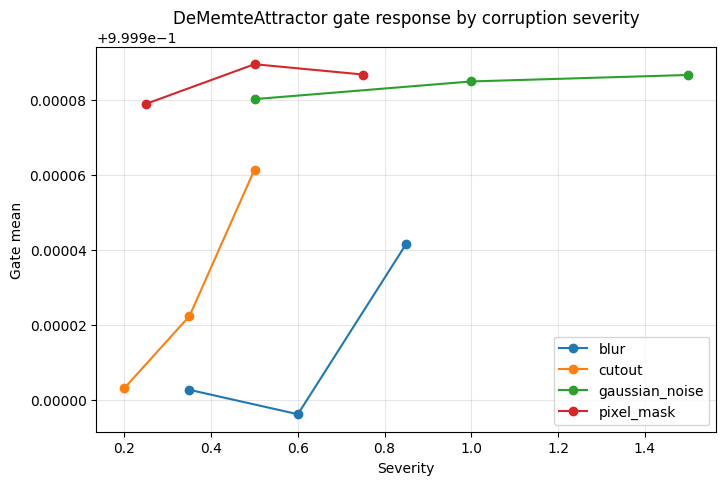

In [18]:
if 'attractor_full' in attractor_eval_details:
    rows = []
    for corr, records in attractor_eval_details['attractor_full'].items():
        for level, rec in zip(strict_suite[corr], records):
            rows.append({'corruption': corr, 'severity': level, 'gate_mean': rec['gate_mean'], 'acc': rec['acc']})
    gate_curve_df = pd.DataFrame(rows) if pd is not None else rows
    display(gate_curve_df)
    fig, ax = plt.subplots(figsize=(8, 5))
    if pd is not None:
        grouped = gate_curve_df.groupby('corruption')
        for corr, sub in grouped:
            ax.plot(sub['severity'], sub['gate_mean'], marker='o', label=corr)
    else:
        for corr in sorted({row['corruption'] for row in rows}):
            sub = [row for row in rows if row['corruption'] == corr]
            ax.plot([row['severity'] for row in sub], [row['gate_mean'] for row in sub], marker='o', label=corr)
    ax.set_xlabel('Severity')
    ax.set_ylabel('Gate mean')
    ax.set_title('DeMemteAttractor gate response by corruption severity')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

## Discussion

Acceptance signals to inspect after execution:

- Clean accuracy should match or improve the current DeMemte reference.
- Blur and cutout corrupt accuracy should improve relative to current DeMemte.
- Gate should be higher for recoverable ambiguous corruptions than for heavy Gaussian noise.
- Harmful changes and pareidolia rate should be lower than the entropy-only gate variant.
- The gate-vs-severity plot should show a non-monotonic response for recoverable vs extreme corruption.